# Prepare data

In [574]:
from sklearn.datasets import make_moons
import numpy as np
import torch 
from matplotlib import pyplot as plt
import random

In [575]:
X, y = make_moons(n_samples=200, noise=0.2, random_state=10)

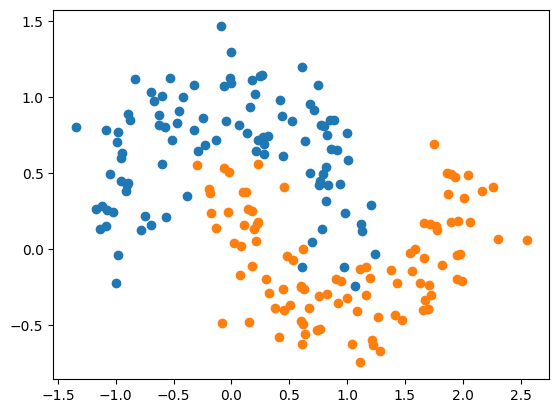

In [576]:
plt.scatter(X[y==0, 0], X[y==0, 1])
plt.scatter(X[y==1, 0], X[y==1, 1])

In [578]:
train_data , train_out = X[:150], y[:150]
test_data, test_out = X[151:], y[151:]


In [579]:
from typing import Any


class Neuron:
    def __init__(self, nin) -> None:
        self.w = torch.tensor([random.uniform(-1,1) for i in range(nin)], requires_grad=True)
        self.bias = torch.tensor(random.uniform(-1,1), requires_grad=True)
        
    def __call__(self, x) -> Any:
        output = torch.dot(x, self.w) + self.bias
        out = output.sigmoid()
        return out
    
    def parameters(self):
        return [self.w, self.bias]
    
    
    
class Layer:
    def __init__(self, ni, nn) -> None:
        self.neurons = [ Neuron(ni) for i in range(nn)]
        
    def __call__(self, x) -> Any:
        outs = torch.stack([neu(x) for neu in self.neurons])        
        return outs
        
    def parameters(self):
        params = [] 
        for neu in self.neurons:
            params.extend(neu.parameters())
        
        return params
    
class MLP:
    def __init__(self, ni, nl) -> None:
        self.sz = [ni] + nl
        self.layers = [ Layer(self.sz[i], self.sz[i+1]) for i in range(len(self.sz)-1) ]
        
    def __call__(self, x):
        for l in self.layers:
            x = l(x)
        return x
    
    def parameters(self):
        params = [] 
        for layer in self.layers:
            params.extend(layer.parameters())
        return params             

In [581]:
mlp = MLP(2, [4,4,1])

In [435]:
loss = torch.tensor(0.0)
for t, to in zip(train_data, train_out):
    v = mlp(torch.tensor(t).float()).sigmoid()
    error = v - torch.tensor(to)
    loss = loss + (error ** 2)

for p in mlp.parameters():
    p = torch.tensor(0.0, requires_grad=True)

loss.backward()
# print(mlp.parameters())
for p in mlp.parameters():
    p.data = p.data + (-0.001 * p.grad)

print(loss.item())

5.848744869232178


In [735]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Lower your learning rate
optimizer = optim.SGD(mlp.parameters(), lr=0.5) 

# 2. Use Binary Cross Entropy Loss for Sigmoid outputs
criterion = nn.BCELoss() 

epochs = 100

for epoch in range(epochs):
    # Zero gradients at the START of the epoch
    optimizer.zero_grad()
    
    epoch_loss = torch.tensor(0.0)
    
    # Calculate loss for the ENTIRE dataset (Batch Gradient Descent)
    for t, to in zip(train_data, train_out):
        # Forward pass
        pred = mlp(torch.tensor(t).float())
        target = torch.tensor([to]).float() # Target must match prediction shape
        
        # Calculate BCE Loss
        loss = criterion(pred, target)
        epoch_loss = epoch_loss + loss
        
    # Average the loss over the number of samples
    epoch_loss = epoch_loss / len(train_data)
    
    # 3. Backward pass and update weights ONCE per epoch
    epoch_loss.backward()
    optimizer.step()
    
    # Record the smooth epoch loss
    loss_history = epoch_loss.item()

loss_history

0.026052407920360565

In [736]:
for ti, to in zip(test_data[25:], test_out[25:]):
    res = mlp(torch.tensor(ti).float())
    print(res, to)

tensor([1.7596e-05], grad_fn=<StackBackward0>) 0
tensor([6.1076e-07], grad_fn=<StackBackward0>) 0
tensor([1.0000], grad_fn=<StackBackward0>) 1
tensor([0.9997], grad_fn=<StackBackward0>) 1
tensor([6.4560e-07], grad_fn=<StackBackward0>) 0
tensor([0.0003], grad_fn=<StackBackward0>) 0
tensor([1.0000], grad_fn=<StackBackward0>) 1
tensor([0.0003], grad_fn=<StackBackward0>) 1
tensor([0.0033], grad_fn=<StackBackward0>) 0
tensor([1.0000], grad_fn=<StackBackward0>) 1
tensor([0.9938], grad_fn=<StackBackward0>) 1
tensor([1.7098e-06], grad_fn=<StackBackward0>) 0
tensor([1.0000], grad_fn=<StackBackward0>) 0
tensor([5.4096e-07], grad_fn=<StackBackward0>) 0
tensor([0.0042], grad_fn=<StackBackward0>) 0
tensor([1.0000], grad_fn=<StackBackward0>) 1
tensor([0.3452], grad_fn=<StackBackward0>) 1
tensor([1.0000], grad_fn=<StackBackward0>) 1
tensor([1.0000], grad_fn=<StackBackward0>) 1
tensor([1.0000], grad_fn=<StackBackward0>) 1
tensor([7.5767e-07], grad_fn=<StackBackward0>) 0
tensor([0.1150], grad_fn=<Stack